# 04 · Mechanism & Behavior (Exp3) — *how / why / who?* (method-symmetric)

Behavior decomposition (MITI counts + text drift) → reward faithfulness + rubric factor structure →
descriptive heterogeneity by **true persona** → session-end / conversation length → persona-matched
transcript evolution. Every per-arm analysis runs for **all arms** (both methods).

In [1]:
import sys, os; sys.path.insert(0, os.path.abspath("."))           # cwd = eda/ -> `import exp3`
import warnings; warnings.filterwarnings("ignore")
import numpy as np, pandas as pd, matplotlib.pyplot as plt, seaborn as sns
pd.set_option("display.width", 185, "display.max_columns", 50)
import exp3
from exp3 import stats, behavior, training, pref, figures, plots
S = exp3.notebook_setup()      # S.ARMS, S.SCORES, S.PALETTE, S.METRICS, S.ORACLE_NOISE, S.RESULTS_DIR

arms on disk: [('PTO_LA0', 11), ('PTO_LA5', 6), ('GRPO_LA0', 6), ('GRPO_LA5', 2)]
scores_long: (16128, 19) | arms scored: ['GRPO_LA0', 'GRPO_LA5', 'PTO_LA0', 'PTO_LA5']
exports -> C:\Users\baruc\Desktop\Projects\Thesis_PTO_GRPO\Exp3_PTO_GRPO\eda\results


In [2]:
GENS = training.load_generations(S.ARMS)
BEH = behavior.behavior_by_iter(S.ARMS)

## 1 · Behavior trajectories (all arms) + per-arm tables

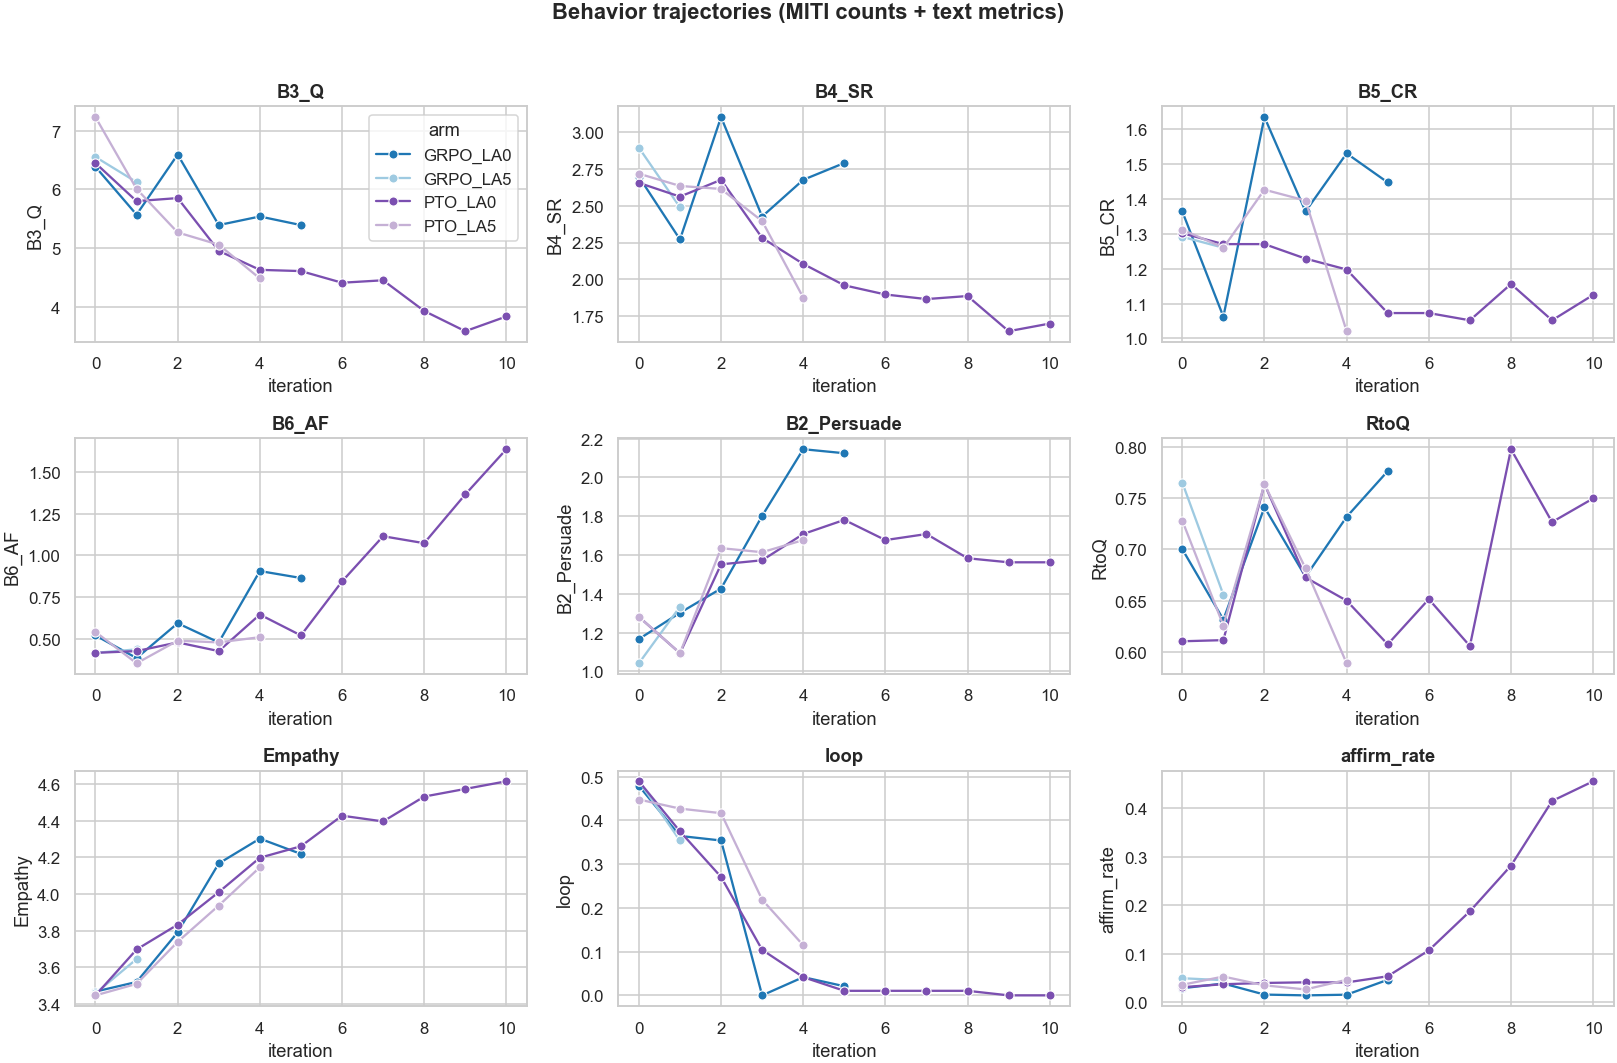


=== GRPO_LA0 behavior by iteration ===


,iteration,B3_Q,B4_SR,B5_CR,B6_AF,B2_Persuade,RtoQ,Empathy,loop,affirm_rate
0,0,6.385,2.698,1.365,0.521,1.167,0.700,3.469,0.479,0.029
1,1,5.573,2.271,1.062,0.385,1.302,0.632,3.521,0.365,0.039
2,2,6.594,3.104,1.635,0.594,1.427,0.741,3.792,0.354,0.016
3,3,5.396,2.427,1.365,0.479,1.802,0.673,4.167,0.000,0.014
4,4,5.542,2.677,1.531,0.906,2.146,0.732,4.302,0.042,0.016
5,5,5.396,2.792,1.448,0.865,2.125,0.776,4.219,0.021,0.046



=== GRPO_LA5 behavior by iteration ===


,iteration,B3_Q,B4_SR,B5_CR,B6_AF,B2_Persuade,RtoQ,Empathy,loop,affirm_rate
6,0,6.552,2.896,1.292,0.417,1.042,0.765,3.458,0.490,0.050
7,1,6.125,2.490,1.260,0.438,1.333,0.656,3.646,0.354,0.046



=== PTO_LA0 behavior by iteration ===


,iteration,B3_Q,B4_SR,B5_CR,B6_AF,B2_Persuade,RtoQ,Empathy,loop,affirm_rate
8,0,6.448,2.656,1.302,0.417,1.281,0.610,3.448,0.490,0.031
9,1,5.802,2.562,1.271,0.427,1.094,0.612,3.698,0.375,0.037
10,2,5.854,2.677,1.271,0.479,1.552,0.764,3.833,0.271,0.040
11,3,4.958,2.281,1.229,0.427,1.573,0.673,4.010,0.104,0.041
12,4,4.635,2.104,1.198,0.646,1.708,0.650,4.198,0.042,0.041
13,5,4.615,1.958,1.073,0.521,1.781,0.607,4.260,0.010,0.054
14,6,4.417,1.896,1.073,0.844,1.677,0.652,4.427,0.010,0.107
15,7,4.458,1.865,1.052,1.115,1.708,0.606,4.396,0.010,0.188
16,8,3.938,1.885,1.156,1.073,1.583,0.798,4.531,0.010,0.282
17,9,3.594,1.646,1.052,1.365,1.562,0.727,4.573,0.000,0.415



=== PTO_LA5 behavior by iteration ===


,iteration,B3_Q,B4_SR,B5_CR,B6_AF,B2_Persuade,RtoQ,Empathy,loop,affirm_rate
19,0,7.229,2.719,1.312,0.542,1.281,0.728,3.448,0.448,0.036
20,1,6.010,2.635,1.260,0.354,1.094,0.626,3.510,0.427,0.053
21,2,5.271,2.615,1.427,0.490,1.635,0.764,3.740,0.417,0.035
22,3,5.062,2.396,1.396,0.479,1.615,0.682,3.938,0.219,0.027
23,4,4.490,1.875,1.021,0.510,1.677,0.589,4.146,0.115,0.046


In [3]:
fig = plots.behavior_trajectory_grid(BEH)
if fig: exp3.save_fig(fig, "behavior_drift", caption="MITI behavior counts (B3_Q questions, B4_SR/B5_CR reflections, B6_AF affirmations, B2_Persuade) + text metrics across iterations, all arms."); plt.show()
BM = [m for m in ["B3_Q", "B4_SR", "B5_CR", "B6_AF", "B2_Persuade", "RtoQ", "Empathy", "loop", "affirm_rate"] if m in BEH.columns]
for arm in sorted(BEH.arm.unique()):
    BT = BEH[BEH.arm == arm][["iteration"] + BM].round(3)
    print(f"\n=== {arm} behavior by iteration ==="); display(BT)
    exp3.save_table(BT, f"{arm}_behavior_by_iter", caption=f"{arm} mean behavior metrics per iteration (MITI counts + text metrics).")

## 2 · Reward faithfulness + rubric factor structure

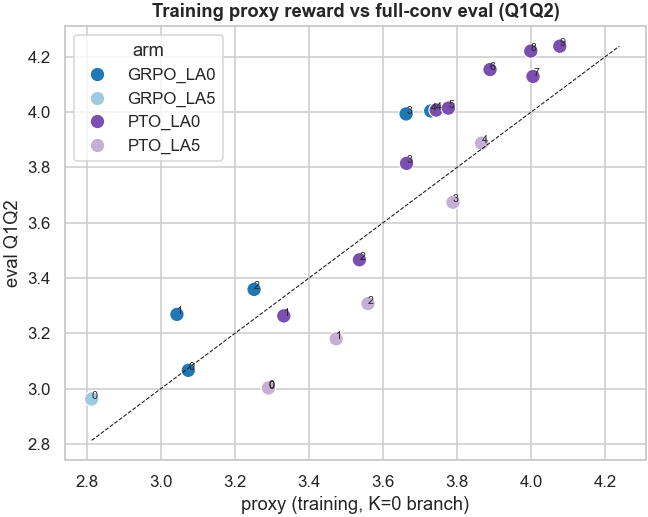

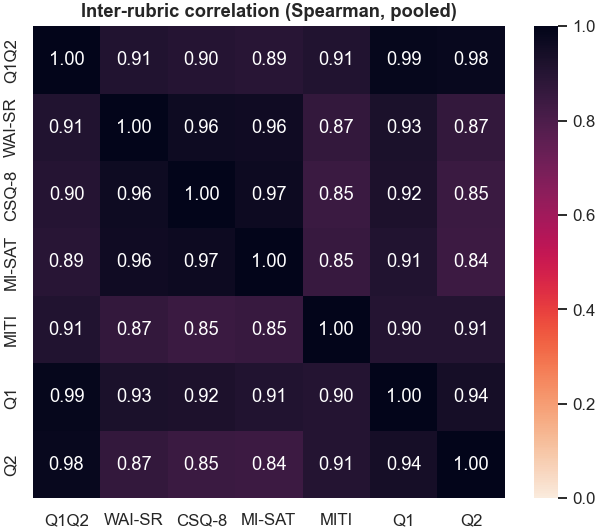

GRPO_LA0: PC1 = 92.1%  loadings={'Q1Q2': 0.447, 'WAI-SR': 0.45, 'CSQ-8': 0.451, 'MI-SAT': 0.456, 'MITI': 0.433}
GRPO_LA5: PC1 = 93.3%  loadings={'Q1Q2': 0.439, 'WAI-SR': 0.451, 'CSQ-8': 0.452, 'MI-SAT': 0.451, 'MITI': 0.444}
PTO_LA0: PC1 = 90.7%  loadings={'Q1Q2': 0.442, 'WAI-SR': 0.454, 'CSQ-8': 0.452, 'MI-SAT': 0.455, 'MITI': 0.432}
PTO_LA5: PC1 = 91.6%  loadings={'Q1Q2': 0.437, 'WAI-SR': 0.452, 'CSQ-8': 0.452, 'MI-SAT': 0.454, 'MITI': 0.441}


In [4]:
fig = plots.faithfulness_proxy_vs_eval(S.SCORES, GENS)   # canonical save lives in 00; display only here
if fig: plt.show()
fig = plots.rubric_correlation_heatmap(S.SCORES)
exp3.save_fig(fig, "rubric_correlation", caption="Spearman correlation among the rubric scores (per conversation, pooled)."); plt.show()
for arm in sorted(S.SCORES.arm.unique()):
    p = stats.rubric_pca(S.SCORES[S.SCORES.arm == arm])
    if p["explained_variance_ratio"]:
        print(f"{arm}: PC1 = {p['explained_variance_ratio'][0]:.1%}  loadings={p['pc1_loadings']}")

## 3 · Descriptive / exploratory — heterogeneity by true persona

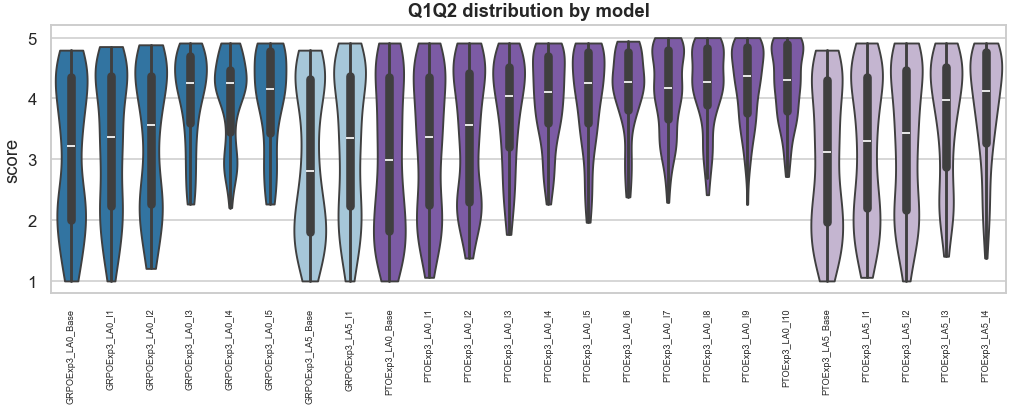

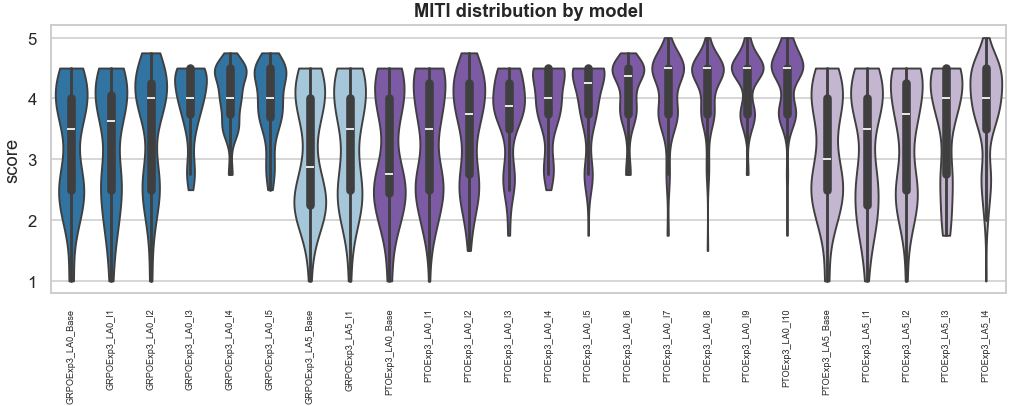

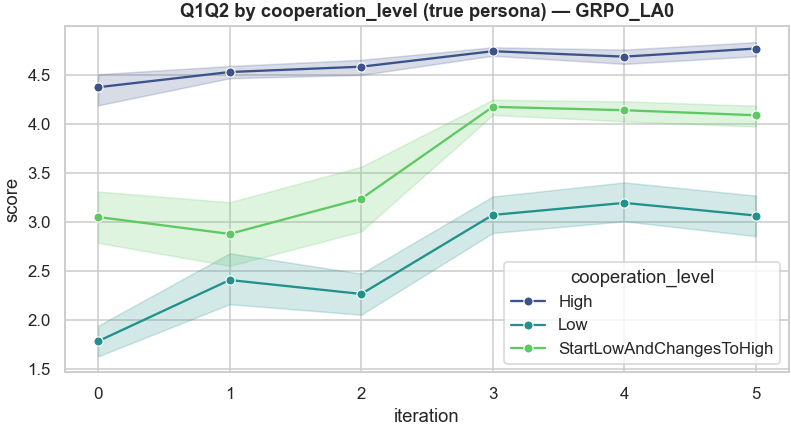

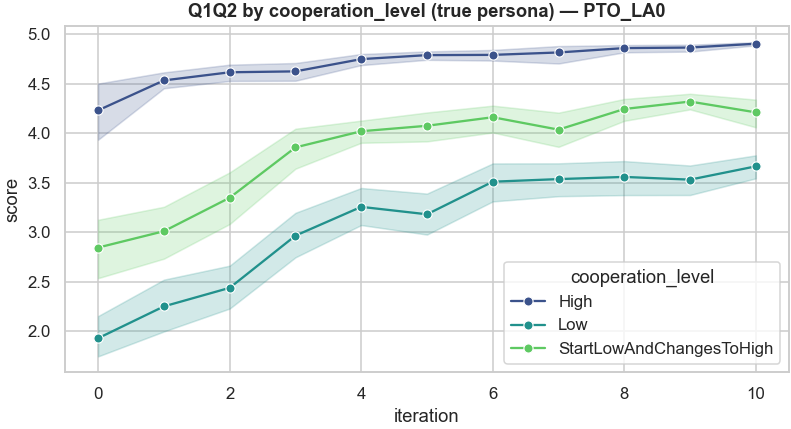

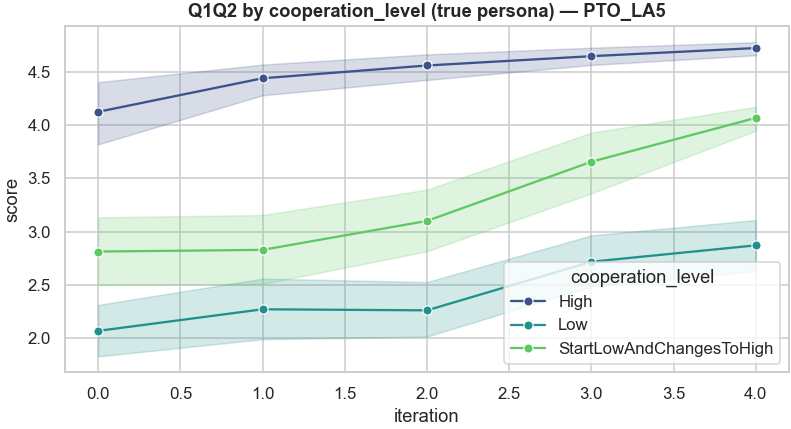

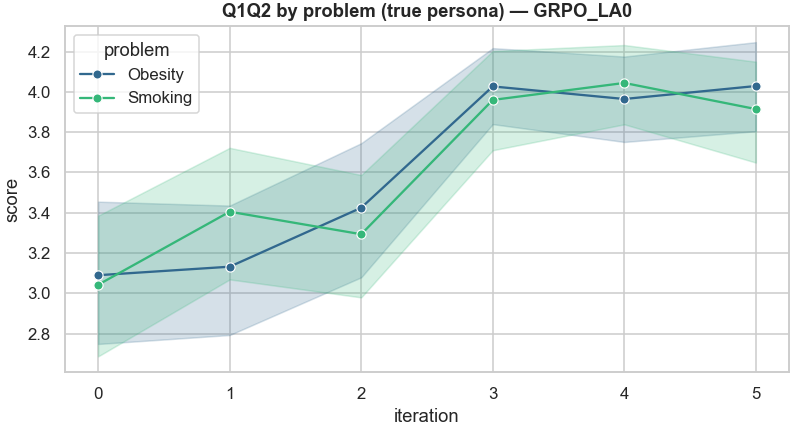

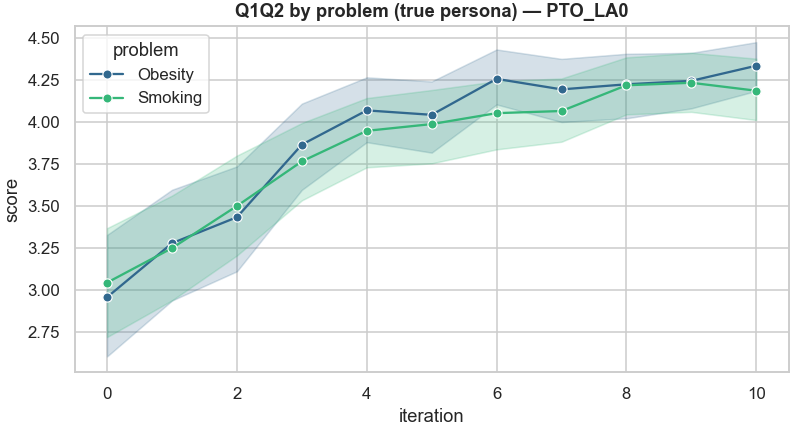

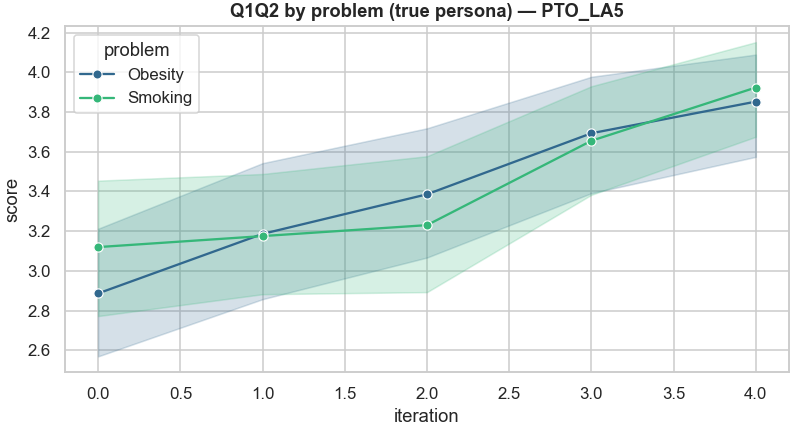

In [5]:
for m in ["Q1Q2", "MITI"]:
    fig = plots.score_violin_by_model(S.SCORES, m, palette=S.PALETTE); plt.show()
for char in ["cooperation_level", "problem"]:
    for arm in sorted(S.SCORES.arm.unique()):
        d = S.SCORES[(S.SCORES.arm == arm) & (S.SCORES.questionnaire == "Q1Q2")]
        if d.iteration.nunique() < 3 or char not in d.columns:
            continue
        fig, ax = plt.subplots(figsize=(7.5, 4.2))
        sns.lineplot(d, x="iteration", y="score", hue=char, marker="o", palette="viridis", ax=ax)
        ax.set_title(f"Q1Q2 by {char} (true persona) — {arm}"); fig.tight_layout()
        exp3.save_fig(fig, f"heterogeneity_{char}_{arm}", caption=f"{arm} Q1+Q2 across iterations split by true patient {char}."); plt.show()

## 4 · Session-end reasons + conversation length

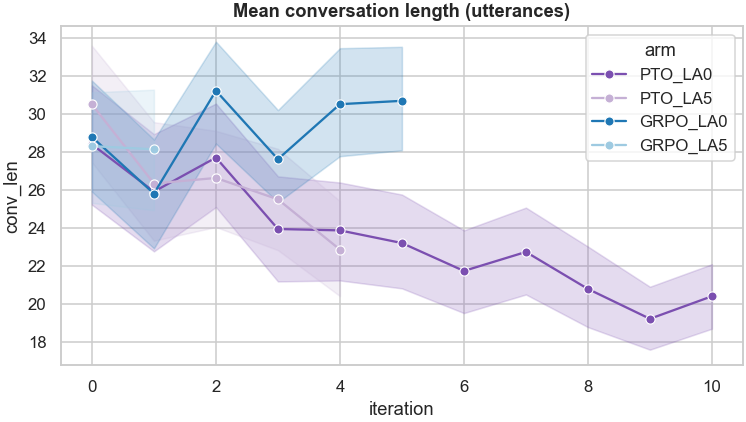

ended_by,nan,patient,therapist
arm,,,
GRPO_LA0,134.0,439.0,3.0
GRPO_LA5,61.0,128.0,3.0
PTO_LA0,178.0,871.0,7.0
PTO_LA5,127.0,349.0,4.0


In [6]:
TEXT = behavior.text_metrics(S.ARMS, attach_persona=False)
fig, ax = plt.subplots(figsize=(8, 4))
sns.lineplot(TEXT, x="iteration", y="conv_len", hue="arm", palette=figures.arm_palette(sorted(TEXT.arm.unique())), marker="o", ax=ax)
ax.set_title("Mean conversation length (utterances)"); plt.show()
rows = []
for a in S.ARMS:
    for k in a.iters:
        cdir = a.conv_dir(k)
        for fn in (os.listdir(cdir) if cdir and os.path.isdir(cdir) else []):
            if fn.startswith("conversation_") and fn.endswith(".csv"):
                try: dd = pd.read_csv(os.path.join(cdir, fn))
                except Exception: continue
                rows.append({"arm": a.label, "ended_by": str(dd["session_ended_by"].iloc[0]) if "session_ended_by" in dd else "NA"})
if rows:
    display(pd.DataFrame(rows).groupby(["arm", "ended_by"]).size().rename("n").reset_index()
            .pivot_table(index="arm", columns="ended_by", values="n", fill_value=0))

## 5 · Persona-matched transcript evolution (all arms)

In [7]:
from exp3.personas import persona_order
def file_of_persona(seed, k, pid, n=96): return persona_order(seed, k, n).index(pid)
PERSONA = 0
print("persona", PERSONA, "=", exp3.canonical_personas().loc[PERSONA].to_dict(), "\n")
for arm in S.ARMS:
    iters = arm.iters
    pick = sorted(set([iters[0], iters[len(iters) // 2], iters[-1]]))
    print(f"\n############  {arm.label}  ############")
    for k in pick:
        cdir = arm.conv_dir(k)
        if not cdir: continue
        fi = file_of_persona(arm.seed, k, PERSONA)
        fp = os.path.join(cdir, f"conversation_{fi}.csv")
        if not os.path.exists(fp): continue
        d = pd.read_csv(fp); th = d[d.role == "therapist"]["conversation"].astype(str).tolist()
        print(f"==== {arm.label} model_iter_{k} (conv_{fi}) — {len(th)} therapist turns ====")
        for t in th[1:4]:
            print("   •", " ".join(t.split())[:240]); print()

persona 0 = {'gender': 'Male', 'age_value': 27, 'problem': 'Smoking', 'problem_time': 'FewMonths', 'tried_to_solve': 'Never', 'cooperation_level': 'Low'} 


############  PTO_LA0  ############
==== PTO_LA0 model_iter_0 (conv_14) — 10 therapist turns ====
   • I can understand that. Let's talk about your goals. What's the point of this session?

   • OK, so why don't we start by talking about what it is you enjoy about smoking?

   • I can see that. So what do you enjoy about it? Are there any specific activities you like to do?

==== PTO_LA0 model_iter_5 (conv_54) — 8 therapist turns ====
   • Oh, right, well that’s ok. Let’s talk about what motivates you to want to stop smoking. What do you see as the biggest barrier to doing so?

   • That’s fair. So, how do you want to approach this conversation? What would you like to achieve from our time together?

   • Oh, I totally understand. I can relate to that. I’m here to help you understand why quitting smoking is important and how you ca

## 6 · Takeaways
- The **affirmation-drift** signature (B6_AF up, turn length up, B3_Q down) is what to watch across §1 —
  compare its onset between PTO and GRPO at matched late iterations.
- **Faithfulness (§2):** points below the y=x line mean the short training proxy over-rates the policy —
  the motivation for MIN_CONV_LENGTH.
- **PC1 share (§2):** a dominant PC1 means "all rubrics up" is largely one latent factor, weak evidence of
  multi-skill gain.
- **Heterogeneity (§3):** which personas (cooperation level / problem) benefit most.